# Quantum 2×2 Sudoku Solver using Grover's Algorithm

**Course:** Advanced Computer Architecture — Final Project  
**Framework:** IBM Qiskit · AerSimulator

---

## Overview

This notebook implements **Grover's quantum search algorithm** to solve a 2×2 Sudoku puzzle.  
The quantum circuit searches all possible cell assignments simultaneously and amplifies the probability of valid solutions.

### 2×2 Sudoku Rules

The grid contains values from **{1, 2}** such that:
- Every **row** contains distinct values
- Every **column** contains distinct values

```
┌───┬───┐
│ ? │ ? │   Row 0: cell[0,0] ≠ cell[0,1]
├───┼───┤
│ ? │ ? │   Row 1: cell[1,0] ≠ cell[1,1]
└───┴───┘
Col 0: cell[0,0] ≠ cell[1,0]     Col 1: cell[0,1] ≠ cell[1,1]
```

### Binary Encoding

| Digit | Qubit State |
|-------|-------------|
| 1     | \|0⟩        |
| 2     | \|1⟩        |

### Grover's Algorithm — Key Idea

Given a search space of N states with M marked states (solutions), Grover's algorithm finds a solution in **O(√(N/M))** iterations, compared to **O(N/M)** for classical search.

**Three components:**
1. **Superposition** — initialize all states equally with Hadamard gates
2. **Oracle** — flip the phase of valid solution states
3. **Diffusion** — amplify the probability of phase-flipped states

The optimal number of iterations: $k = \left\lfloor \frac{\pi}{4} \sqrt{\frac{N}{M}} \right\rceil$

---
## 1. Setup & Imports

In [17]:
# ── Dependency Installation ───────────────────────────────────────────────────
# Option A — Conda environment (recommended, from project root):
#   conda env create -f environment.yml
#   conda activate quantum-sudoku
#
# Option B — pip inside an already-active conda env:
#   pip install -r requirements.txt
#
# After activating the env, register it as a Jupyter kernel (one-time):
#   python -m ipykernel install --user --name quantum-sudoku --display-name "Python (quantum-sudoku)"
# ─────────────────────────────────────────────────────────────────────────────

%matplotlib inline

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print(f"matplotlib backend : {matplotlib.get_backend()}")
print("All packages loaded successfully.")

matplotlib backend : inline
All packages loaded successfully.


---
## 2. SudokuPuzzle — Problem Definition & Classical Verification

This class encodes the 2×2 Sudoku structure and provides classical brute-force verification to confirm which states the quantum algorithm should find.

In [18]:
class SudokuPuzzle:
    """
    2×2 Sudoku puzzle with binary-encoded cell values.

    Grid layout (cell index → qubit index):

          col 0   col 1
    row 0 [ q0 ]  [ q1 ]
    row 1 [ q2 ]  [ q3 ]

    Encoding:  digit '1' → qubit |0⟩,  digit '2' → qubit |1⟩

    Sudoku constraints (all must hold):
        Row 0:  q0 ≠ q1
        Row 1:  q2 ≠ q3
        Col 0:  q0 ≠ q2
        Col 1:  q1 ≠ q3
    """

    # Each entry: (cell_i, cell_j, human-readable description)
    CONSTRAINTS = [
        (0, 1, "Row 0: cell[0,0] ≠ cell[0,1]"),
        (2, 3, "Row 1: cell[1,0] ≠ cell[1,1]"),
        (0, 2, "Col 0: cell[0,0] ≠ cell[1,0]"),
        (1, 3, "Col 1: cell[0,1] ≠ cell[1,1]"),
    ]

    def __init__(self):
        self.solutions = self._find_all_solutions()

    # ── Constraint checking ───────────────────────────────────────────────────

    @staticmethod
    def is_valid(q: list) -> bool:
        """Return True if the 4-element binary assignment satisfies all constraints."""
        return (
            q[0] != q[1] and   # Row 0
            q[2] != q[3] and   # Row 1
            q[0] != q[2] and   # Col 0
            q[1] != q[3]       # Col 1
        )

    def _find_all_solutions(self):
        """Brute-force enumerate all 16 possible states and keep valid ones."""
        solutions = []
        for state in range(16):                          # 2^4 = 16 possible states
            q = [(state >> i) & 1 for i in range(4)]    # extract 4 bits LSB-first
            if self.is_valid(q):
                solutions.append(q)
        return solutions

    # ── Display helpers ───────────────────────────────────────────────────────

    def print_grid(self, q: list, title: str = "Grid"):
        """Pretty-print a 2×2 Sudoku grid."""
        print(f"\n{title}")
        print("┌───┬───┐")
        print(f"│ {q[0]+1} │ {q[1]+1} │   ← binary: {q[0]}{q[1]}")
        print("├───┼───┤")
        print(f"│ {q[2]+1} │ {q[3]+1} │   ← binary: {q[2]}{q[3]}")
        print("└───┴───┘")

    def summarize(self):
        """Print the puzzle layout and all classical solutions."""
        print("2×2 Sudoku — Find All Valid Arrangements of {1, 2}")
        print("=" * 50)
        print("\nConstraints:")
        for _, _, desc in self.CONSTRAINTS:
            print(f"  • {desc}")
        print(f"\nClassical brute-force found {len(self.solutions)} solution(s):")
        for i, sol in enumerate(self.solutions):
            self.print_grid(sol, f"Solution {i+1}")

In [3]:
puzzle = SudokuPuzzle()
puzzle.summarize()

2×2 Sudoku — Find All Valid Arrangements of {1, 2}

Constraints:
  • Row 0: cell[0,0] ≠ cell[0,1]
  • Row 1: cell[1,0] ≠ cell[1,1]
  • Col 0: cell[0,0] ≠ cell[1,0]
  • Col 1: cell[0,1] ≠ cell[1,1]

Classical brute-force found 2 solution(s):

Solution 1
┌───┬───┐
│ 1 │ 2 │   ← binary: 01
├───┼───┤
│ 2 │ 1 │   ← binary: 10
└───┴───┘

Solution 2
┌───┬───┐
│ 2 │ 1 │   ← binary: 10
├───┼───┤
│ 1 │ 2 │   ← binary: 01
└───┴───┘


---
## 3. Theoretical Grover Analysis

Before building the circuit, we compute the optimal number of Grover iterations and the theoretical success probability.

The geometry of Grover's algorithm: the algorithm rotates the state vector in a 2D plane (spanned by |valid⟩ and |invalid⟩) by angle **2θ** per iteration, where $\sin(\theta) = \sqrt{M/N}$.

Success probability after k iterations: $P(k) = \sin^2\!\left((2k+1)\,\theta\right)$

In [19]:
N = 16                          # 2^4 — total search space
M = len(puzzle.solutions)      # number of valid (marked) states

theta    = np.arcsin(np.sqrt(M / N))
k_opt    = max(1, round(np.pi / (4 * theta)))   # optimal iteration count

def grover_prob(k: int) -> float:
    """Total probability of measuring ANY valid solution after k iterations."""
    return float(np.sin((2 * k + 1) * theta) ** 2)

print(f"Grover's Algorithm — Theoretical Analysis")
print("=" * 50)
print(f"  Search space size  N = {N}  (2^4 states)")
print(f"  Marked solutions   M = {M}")
print(f"  Angle              θ = {theta:.4f} rad  ({np.degrees(theta):.2f}°)")
print(f"  Optimal iterations k = {k_opt}")
print()
print(f"  {'k':>4} | {'P(success)':>12} | {'P(each solution)':>18}")
print("  " + "-" * 42)
for k in range(1, 7):
    p_tot  = grover_prob(k)
    p_each = p_tot / M
    mark   = " ← optimal" if k == k_opt else ""
    print(f"  {k:>4} | {p_tot:>11.2%} | {p_each:>17.2%}{mark}")

Grover's Algorithm — Theoretical Analysis
  Search space size  N = 16  (2^4 states)
  Marked solutions   M = 2
  Angle              θ = 0.3614 rad  (20.70°)
  Optimal iterations k = 2

     k |   P(success) |   P(each solution)
  ------------------------------------------
     1 |      78.13% |            39.06%
     2 |      94.53% |            47.27% ← optimal
     3 |      33.01% |            16.50%
     4 |       1.22% |             0.61%
     5 |      54.80% |            27.40%
     6 |      99.98% |            49.99%


---
## 4. SudokuOracle — Phase Oracle Design

### How the Oracle Works

The oracle must flip the **phase** of valid solution states without disturbing ancilla qubits.

**Qubit registers:**
| Register | Size | Purpose |
|----------|------|---------|
| `sol[0..3]` | 4 | Solution qubits (one per cell) |
| `clause[0..3]` | 4 | Ancilla: one per constraint |
| `out` | 1 | Phase-kickback qubit (initialized to \|−⟩) |

**Oracle steps:**
1. **Compute** — for each constraint `(i, j)`:  `clause[k] = sol[i] XOR sol[j]`  
   `clause[k] = 1` if the constraint is satisfied.
2. **Phase flip** — MCX: if all 4 clause qubits are |1⟩, flip `out`.  
   Since `out` is in |−⟩, this applies a −1 phase to valid states.
3. **Uncompute** — re-apply the same XOR gates to restore clause qubits to |0⟩.

```
sol[0] ──●────────────────────────●────
sol[1] ──⊕──●───────────────────●──⊕──  clause[0] = sol[0]⊕sol[1]
sol[2] ──────────●────────────●──────
sol[3] ──────────⊕──●──────●──⊕──────  clause[1] = sol[2]⊕sol[3]
         ... (col constraints similarly)
clause[0] ──────────────────●──────────
clause[1] ──────────────────●──────────  MCX fires only when
clause[2] ──────────────────●──────────  all clauses = 1
clause[3] ──────────────────●──────────
out |−⟩ ──────────────────⊕──────────  phase kickback → −1
```

In [20]:
class SudokuOracle:
    """
    Phase oracle for the 2×2 Sudoku problem.

    Marks valid solutions by flipping the phase of states that satisfy
    all four uniqueness constraints, using phase kickback via an ancilla
    qubit in the |−⟩ state.
    """

    # Maps (sol_i, sol_j) XOR result → clause_k
    # (sol_i, sol_j, clause_index, constraint_name)
    CLAUSE_MAP = [
        (0, 1, 0, "Row 0"),
        (2, 3, 1, "Row 1"),
        (0, 2, 2, "Col 0"),
        (1, 3, 3, "Col 1"),
    ]

    def _compute_clauses(self, qc, sol, clause):
        """
        XOR-based constraint evaluation.

        This operation is self-inverse: calling it twice restores clause
        qubits to |0⟩, which is used for uncomputation.
        """
        for i, j, k, _ in self.CLAUSE_MAP:
            qc.cx(sol[i], clause[k])    # clause[k] ^= sol[i]
            qc.cx(sol[j], clause[k])    # clause[k] ^= sol[j]  → XOR complete

    def apply(self, qc: QuantumCircuit, sol: list, clause: list, out) -> None:
        """
        Append the oracle to an existing QuantumCircuit.

        Parameters
        ----------
        qc     : target QuantumCircuit
        sol    : list of 4 solution qubits
        clause : list of 4 clause ancilla qubits (must start in |0⟩)
        out    : single output qubit (must be in |−⟩ for phase kickback)
        """
        # Step 1 — compute constraint clauses
        self._compute_clauses(qc, sol, clause)

        # Step 2 — phase flip when all 4 clauses are |1⟩ (all constraints met)
        qc.mcx([clause[0], clause[1], clause[2], clause[3]], out)

        # Step 3 — uncompute (restore clause qubits to |0⟩)
        self._compute_clauses(qc, sol, clause)

    def build_standalone(self) -> QuantumCircuit:
        """Return a standalone QuantumCircuit of just the oracle (for visualization)."""
        sol    = QuantumRegister(4, 'sol')
        clause = QuantumRegister(4, 'clause')
        out    = QuantumRegister(1, 'out')
        qc     = QuantumCircuit(sol, clause, out, name='Sudoku Oracle')
        self.apply(qc, list(sol), list(clause), out[0])
        return qc

Oracle circuit statistics
  Qubits : 9  (4 sol + 4 clause + 1 out)
  Depth  : 9
  Gates  : {'cx': 16, 'mcx': 1}



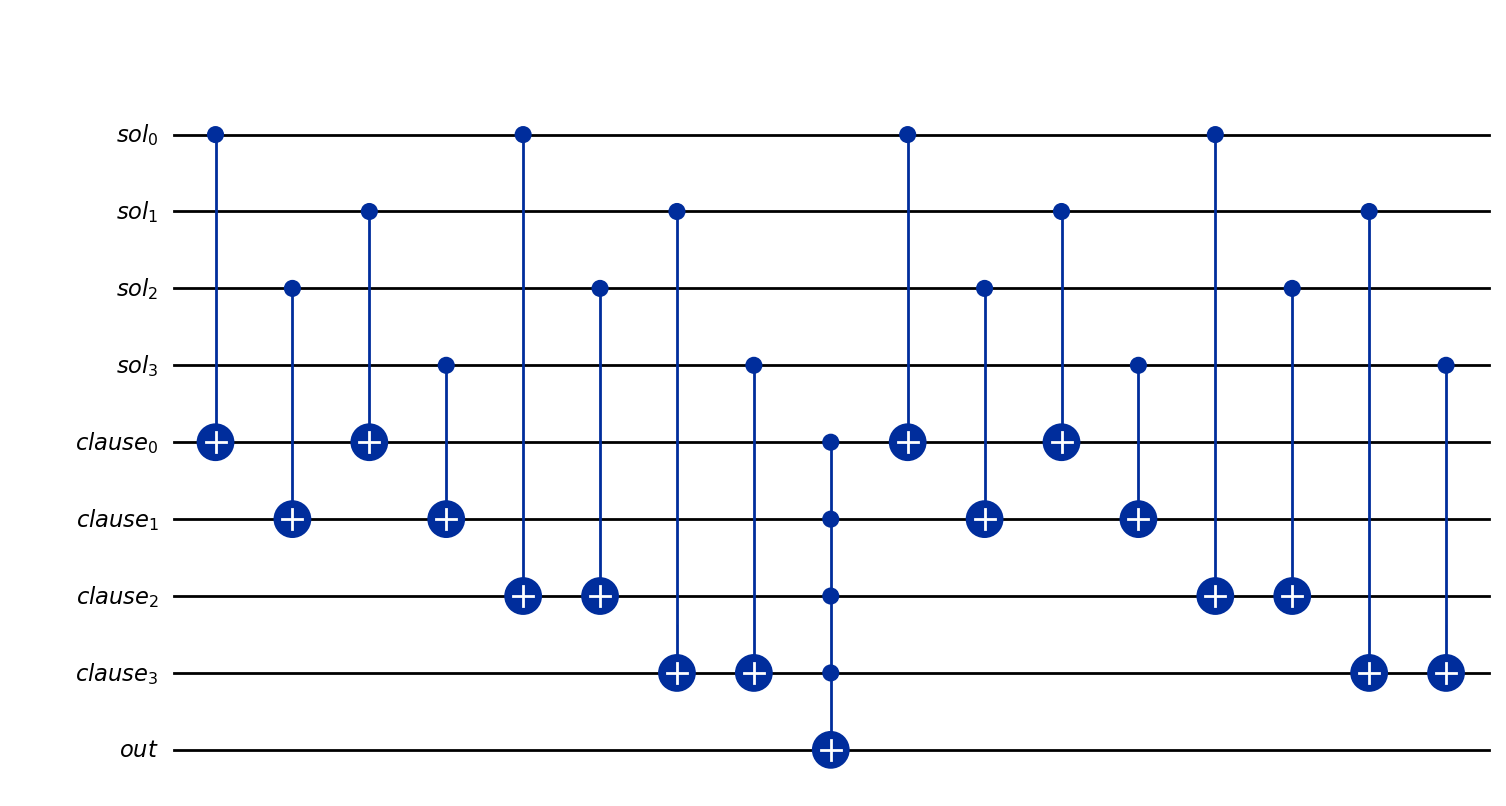

Oracle circuit saved to oracle_circuit.png


In [21]:
oracle = SudokuOracle()
oracle_qc = oracle.build_standalone()

print(f"Oracle circuit statistics")
print(f"  Qubits : {oracle_qc.num_qubits}  ({4} sol + {4} clause + {1} out)")
print(f"  Depth  : {oracle_qc.depth()}")
print(f"  Gates  : {dict(oracle_qc.count_ops())}")
print()

fig = oracle_qc.draw('mpl', fold=-1)
fig.suptitle("Sudoku Phase Oracle", fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('oracle_circuit.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)
print("Oracle circuit saved to oracle_circuit.png")

---
## 5. GroverSolver — Full Algorithm Implementation

### Diffusion Operator

The diffusion operator **2|s⟩⟨s| − I** reflects the state about the uniform superposition |s⟩.

Implementation for n qubits:
$$D = H^{\otimes n} \cdot X^{\otimes n} \cdot H_{n-1} \cdot \text{MCX}(0{:}n{-}2,\, n{-}1) \cdot H_{n-1} \cdot X^{\otimes n} \cdot H^{\otimes n}$$

This implements $2|\mathbf{0}\rangle\langle\mathbf{0}| - I$ in the Hadamard basis, which equals $2|s\rangle\langle s| - I$.

### Full Circuit Architecture

```
  ┌───────────────────────────────────────────────────────┐
  │                                                       │
  │   sol[0..3] ──H──┤         Grover Iteration ├──┤Meas├─
  │                  │                            │      │
  │ clause[0..3] ─0──┤ Oracle ├──0──              │      │
  │                  │                            │      │
  │     out    ──X─H─┤         Diffusion  ├──     │      │
  │                                                       │
  └───────────────────────────────────────────────────────┘
              (repeated k times)
```

In [22]:
class GroverSolver:
    """
    Grover's search algorithm for the 2×2 Sudoku problem.

    Registers
    ---------
    sol[0..3]    : solution qubits (one per Sudoku cell, initialized in |+⟩)
    clause[0..3] : oracle ancilla qubits (workspace, stay |0⟩ outside oracle)
    out          : phase-kickback qubit (initialized to |−⟩ = X·H|0⟩)
    """

    N_SOL    = 4   # solution qubits
    N_CLAUSE = 4   # clause ancilla qubits
    N_OUT    = 1   # phase-kickback qubit

    def __init__(self, oracle: SudokuOracle, n_solutions: int,
                 n_iterations: int = None):
        """
        Parameters
        ----------
        oracle       : SudokuOracle instance
        n_solutions  : number of marked states M
        n_iterations : override for k (computed optimally if None)
        """
        self.oracle = oracle
        N = 2 ** self.N_SOL
        M = max(1, n_solutions)
        self.theta = float(np.arcsin(np.sqrt(M / N)))
        self.k = (
            n_iterations if n_iterations is not None
            else max(1, round(np.pi / (4 * self.theta)))
        )

    # ── Private circuit builders ──────────────────────────────────────────────

    def _initialize(self, qc: QuantumCircuit,
                    sol: QuantumRegister, out: QuantumRegister) -> None:
        """Uniform superposition on sol qubits + |−⟩ on the output qubit."""
        qc.h(list(sol))          # sol → |++++⟩
        qc.x(out[0])             # out → |1⟩
        qc.h(out[0])             # out → |−⟩ = (|0⟩−|1⟩)/√2

    def _diffusion(self, qc: QuantumCircuit, sol: QuantumRegister) -> None:
        """
        Grover diffusion operator: 2|s⟩⟨s| − I

        Reflects amplitudes about the uniform superposition state,
        causing constructive interference on marked states.
        """
        sol_list = list(sol)
        qc.h(sol_list)                           # rotate to computational basis
        qc.x(sol_list)                           # map |0...0⟩ to |1...1⟩
        # Multi-controlled Z via H–MCX–H on the last qubit
        qc.h(sol_list[-1])
        qc.mcx(sol_list[:-1], sol_list[-1])      # C^(n-1) X
        qc.h(sol_list[-1])
        qc.x(sol_list)                           # undo X
        qc.h(sol_list)                           # rotate back

    # ── Public API ────────────────────────────────────────────────────────────

    def build_circuit(self) -> QuantumCircuit:
        """Construct and return the full Grover circuit."""
        sol    = QuantumRegister(self.N_SOL,    'sol')
        clause = QuantumRegister(self.N_CLAUSE, 'clause')
        out    = QuantumRegister(self.N_OUT,    'out')
        cr     = ClassicalRegister(self.N_SOL,  'meas')

        qc = QuantumCircuit(sol, clause, out, cr)

        # ── Stage 1: Initialization ──────────────────────────────────────────
        qc.barrier()
        self._initialize(qc, sol, out)

        # ── Stage 2: Grover iterations ───────────────────────────────────────
        for i in range(self.k):
            qc.barrier()
            self.oracle.apply(qc, list(sol), list(clause), out[0])
            qc.barrier()
            self._diffusion(qc, sol)

        # ── Stage 3: Measurement ─────────────────────────────────────────────
        qc.barrier()
        qc.measure(sol, cr)

        return qc

    def run(self, qc: QuantumCircuit, shots: int = 8192) -> dict:
        """Transpile and simulate on AerSimulator; return measurement counts."""
        backend  = AerSimulator()
        compiled = transpile(qc, backend, optimization_level=1)
        job      = backend.run(compiled, shots=shots)
        return job.result().get_counts()

    @staticmethod
    def decode(bitstring: str) -> list:
        """
        Convert Qiskit measurement bitstring to cell values [q0, q1, q2, q3].

        Qiskit bit ordering: cr[n-1] is leftmost, cr[0] is rightmost.
        So bitstring[n-1-i] gives the value of sol[i].
        """
        n = len(bitstring)
        return [int(bitstring[n - 1 - i]) for i in range(n)]

---
## 6. Build the Circuit

In [23]:
# Instantiate solver with optimal iteration count
solver = GroverSolver(oracle, n_solutions=len(puzzle.solutions))
qc     = solver.build_circuit()

print("Full Grover Circuit — Statistics")
print("=" * 45)
print(f"  Total qubits        : {qc.num_qubits}")
print(f"    Solution qubits   : {solver.N_SOL}  (q0..q3, one per cell)")
print(f"    Clause ancilla    : {solver.N_CLAUSE}  (one per constraint)")
print(f"    Output qubit      : {solver.N_OUT}  (phase kickback)")
print(f"  Classical bits      : {qc.num_clbits}")
print(f"  Circuit depth       : {qc.depth()}")
print(f"  Grover iterations   : {solver.k}  (optimal for N=16, M={len(puzzle.solutions)})")
print(f"  Theoretical P(win)  : {grover_prob(solver.k):.2%}")
print()
print("  Gate counts:")
for gate, count in sorted(qc.count_ops().items(), key=lambda x: -x[1]):
    print(f"    {gate:<12}: {count}")

Full Grover Circuit — Statistics
  Total qubits        : 9
    Solution qubits   : 4  (q0..q3, one per cell)
    Clause ancilla    : 4  (one per constraint)
    Output qubit      : 1  (phase kickback)
  Classical bits      : 4
  Circuit depth       : 35
  Grover iterations   : 2  (optimal for N=16, M=2)
  Theoretical P(win)  : 94.53%

  Gate counts:
    cx          : 32
    h           : 25
    x           : 17
    barrier     : 6
    mcx         : 4
    measure     : 4


Full Grover Circuit (barriers separate Init | Oracle | Diffusion stages):


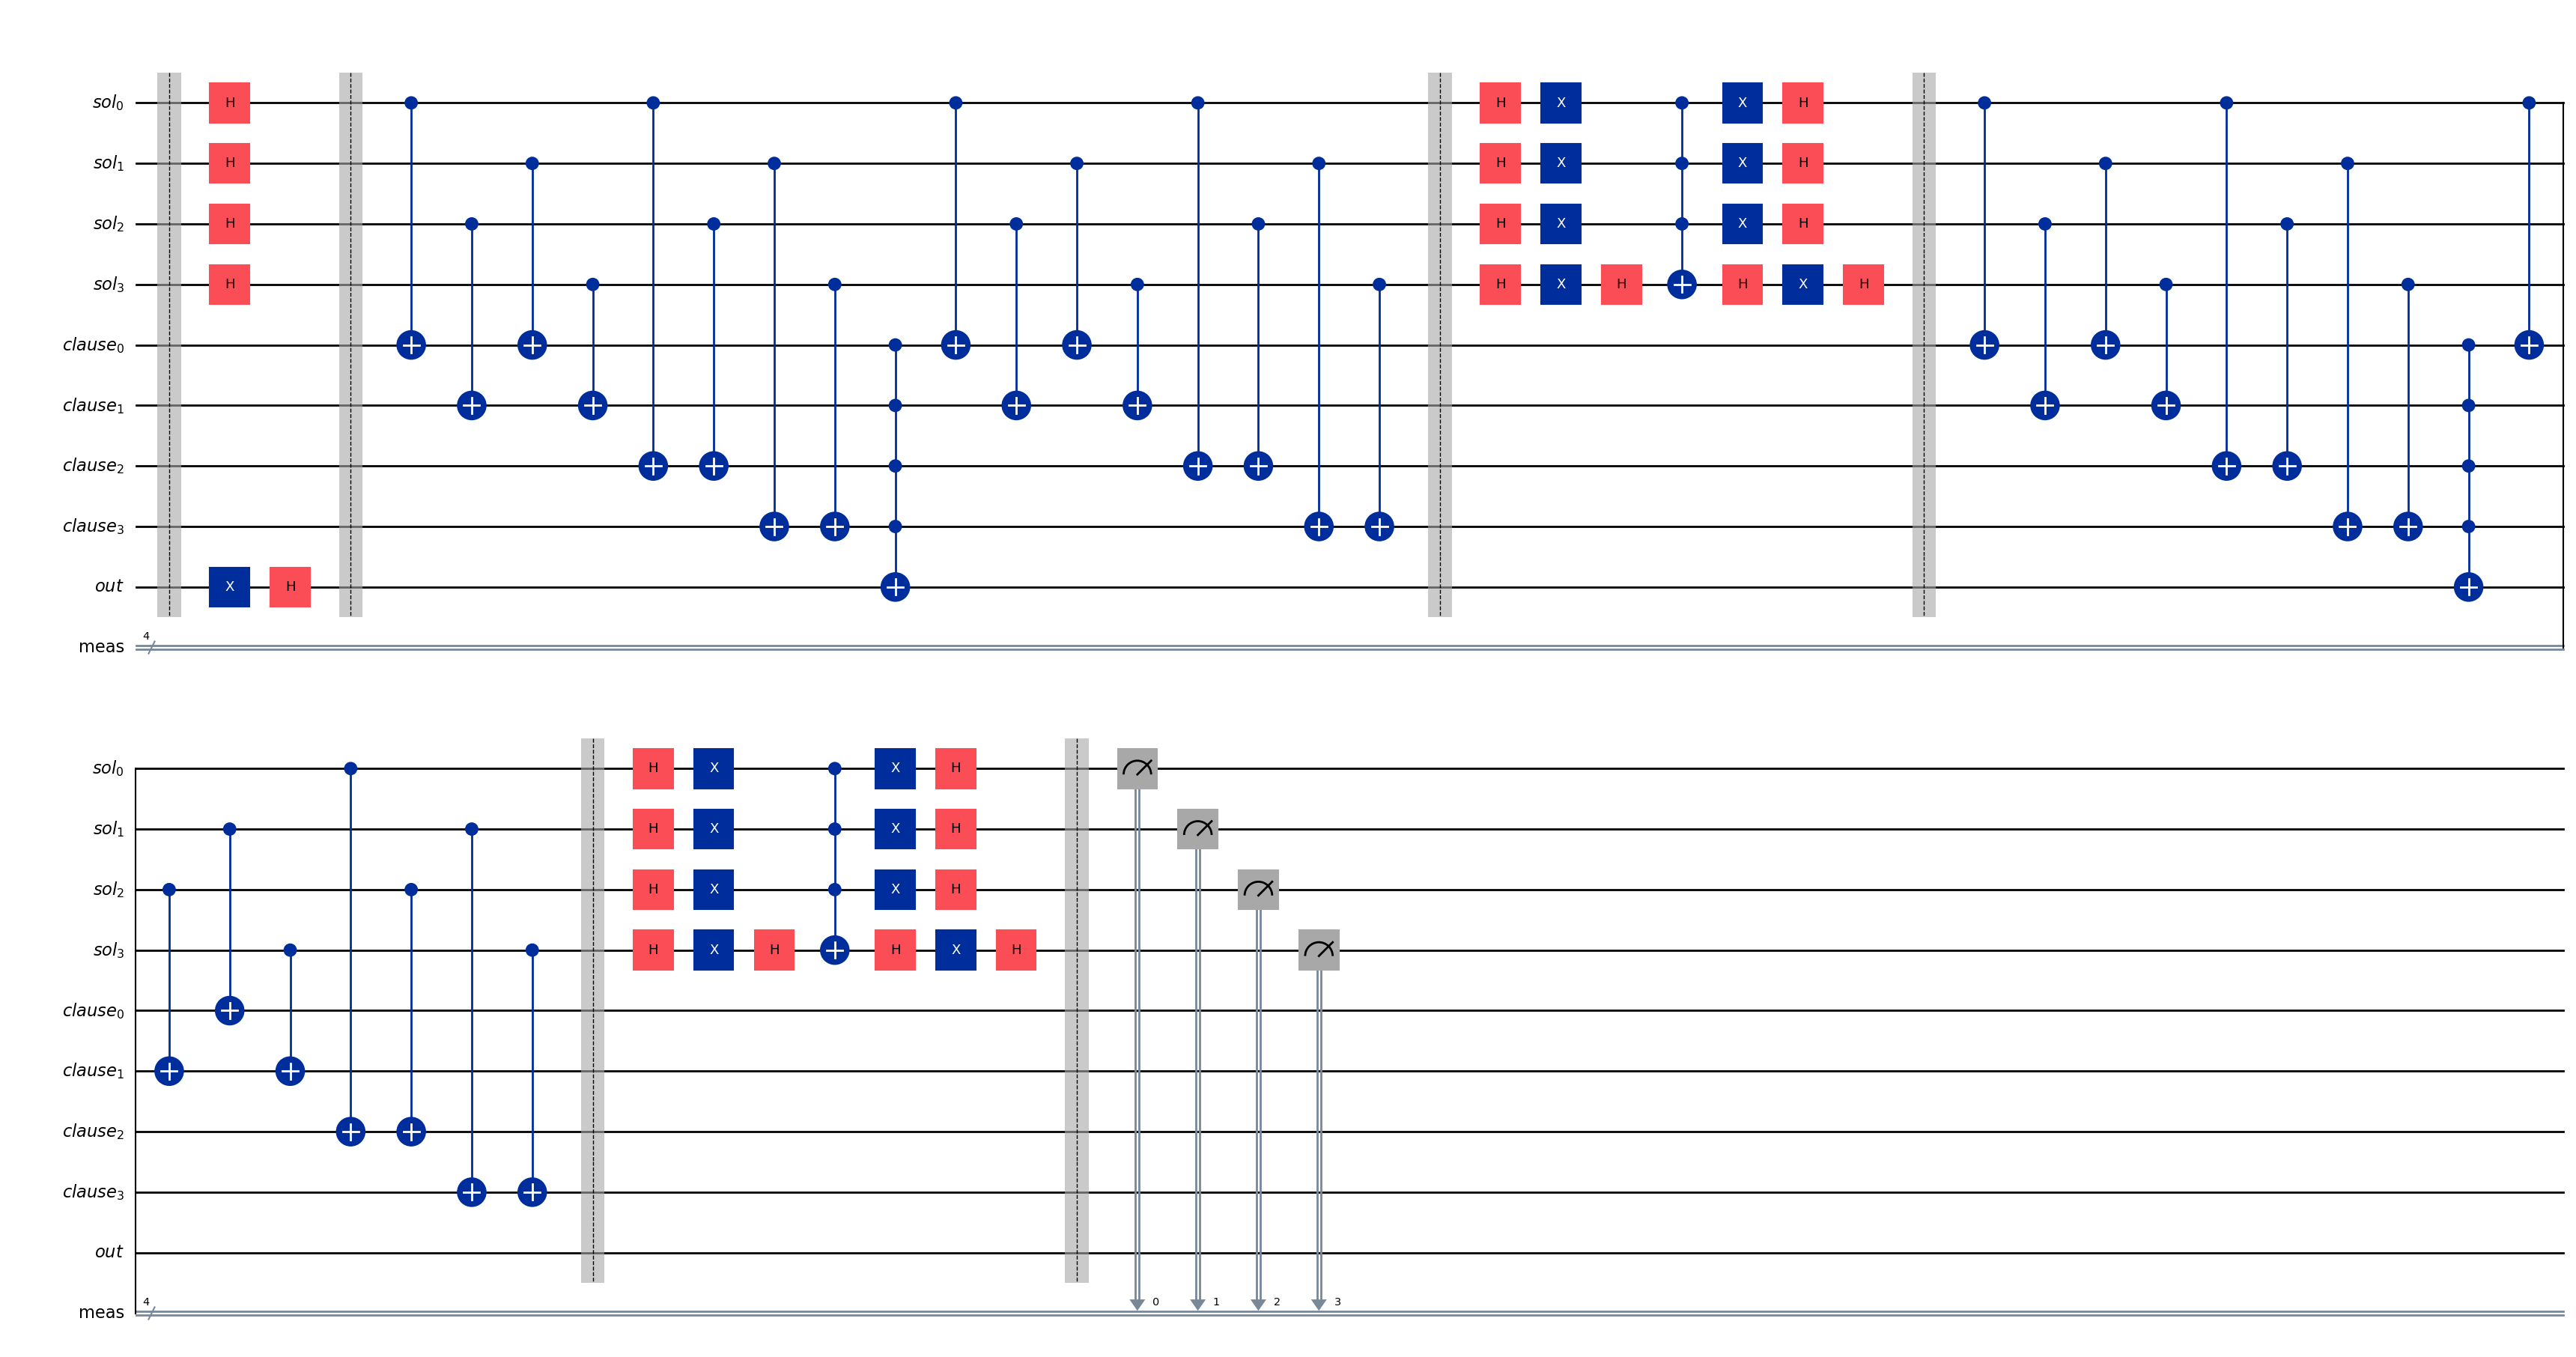

Circuit saved to grover_circuit.png


In [24]:
print("Full Grover Circuit (barriers separate Init | Oracle | Diffusion stages):")
fig = qc.draw('mpl', fold=40)
fig.suptitle(
    f"Grover's Algorithm — 2×2 Sudoku Solver  (k={solver.k} iterations, {qc.num_qubits} qubits)",
    fontsize=11, fontweight='bold', y=1.01
)
fig.tight_layout()
fig.savefig('grover_circuit.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)
print("Circuit saved to grover_circuit.png")

---
## 7. Run the Quantum Simulation

We simulate the circuit on **Qiskit's AerSimulator** — a high-performance statevector/shot-based quantum simulator.

In [25]:
SHOTS = 8192

print(f"Running on AerSimulator with {SHOTS:,} shots...")
counts = solver.run(qc, shots=SHOTS)
total  = sum(counts.values())
print(f"Simulation complete. Unique states observed: {len(counts)}")

# Decode all results
results = [
    {
        'state':     state,
        'count':     count,
        'prob':      count / total,
        'cells':     GroverSolver.decode(state),
        'is_valid':  SudokuPuzzle.is_valid(GroverSolver.decode(state)),
    }
    for state, count in counts.items()
]
results.sort(key=lambda r: -r['count'])

# Print results table
print()
print(f"  {'Bitstring':>10} | {'q3 q2 q1 q0':>12} | {'Count':>6} | {'Probability':>11} | {'Valid?':>7}")
print("  " + "-" * 60)
for r in results[:8]:
    q    = r['cells']
    mark = " ✓" if r['is_valid'] else ""
    print(
        f"  {r['state']:>10} | {q[3]:>2} {q[2]:>2} {q[1]:>2} {q[0]:>2}   "
        f"| {r['count']:>6} | {r['prob']:>10.2%} | {str(r['is_valid']):>7}{mark}"
    )

valid_prob   = sum(r['prob'] for r in results if r['is_valid'])
invalid_prob = 1 - valid_prob
print()
print(f"  Total P(valid solution) measured   : {valid_prob:.2%}")
print(f"  Total P(valid solution) theoretical: {grover_prob(solver.k):.2%}")

Running on AerSimulator with 8,192 shots...
Simulation complete. Unique states observed: 16

   Bitstring |  q3 q2 q1 q0 |  Count | Probability |  Valid?
  ------------------------------------------------------------
        0110 |  0  1  1  0   |   3907 |     47.69% |    True ✓
        1001 |  1  0  0  1   |   3842 |     46.90% |    True ✓
        0010 |  0  0  1  0   |     42 |      0.51% |   False
        1010 |  1  0  1  0   |     40 |      0.49% |   False
        0111 |  0  1  1  1   |     38 |      0.46% |   False
        0000 |  0  0  0  0   |     34 |      0.42% |   False
        0101 |  0  1  0  1   |     33 |      0.40% |   False
        1000 |  1  0  0  0   |     32 |      0.39% |   False

  Total P(valid solution) measured   : 94.59%
  Total P(valid solution) theoretical: 94.53%


---
## 8. Visualize Results

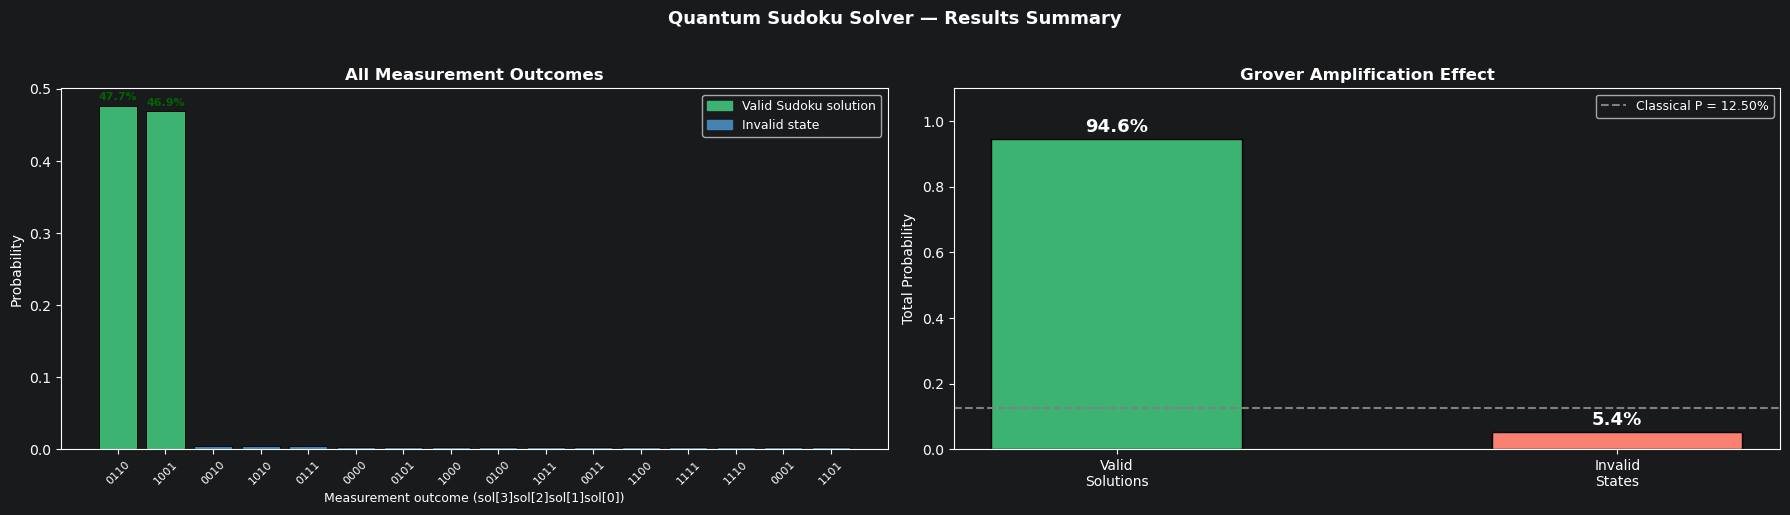

Results plot saved to grover_results.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── Panel 1: Full measurement histogram ──────────────────────────────────────
ax1 = axes[0]
states = [r['state'] for r in results]
probs  = [r['prob']  for r in results]
colors = ['mediumseagreen' if r['is_valid'] else 'steelblue' for r in results]

bars = ax1.bar(states, probs, color=colors, edgecolor='black', linewidth=0.6)
ax1.set_xlabel("Measurement outcome (sol[3]sol[2]sol[1]sol[0])", fontsize=9)
ax1.set_ylabel("Probability")
ax1.set_title("All Measurement Outcomes", fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=8)

# Annotate valid solutions
for r, bar in zip(results, bars):
    if r['is_valid']:
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{r['prob']:.1%}",
            ha='center', va='bottom', fontsize=8, fontweight='bold', color='darkgreen'
        )

legend_handles = [
    mpatches.Patch(color='mediumseagreen', label='Valid Sudoku solution'),
    mpatches.Patch(color='steelblue',      label='Invalid state'),
]
ax1.legend(handles=legend_handles, fontsize=9)

# ── Panel 2: Valid vs. invalid probability ───────────────────────────────────
ax2 = axes[1]
categories = ['Valid\nSolutions', 'Invalid\nStates']
bar_vals   = [valid_prob, invalid_prob]
bar_colors = ['mediumseagreen', 'salmon']

b2 = ax2.bar(categories, bar_vals, color=bar_colors, edgecolor='black', width=0.5)
ax2.set_ylabel("Total Probability")
ax2.set_title("Grover Amplification Effect", fontweight='bold')
ax2.set_ylim(0, 1.1)

# Classical baseline
ax2.axhline(y=M/N, color='gray', linestyle='--', linewidth=1.5, label=f'Classical P = {M/N:.2%}')
ax2.legend(fontsize=9)

for bar, val in zip(b2, bar_vals):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.02,
        f'{val:.1%}',
        ha='center', fontsize=13, fontweight='bold'
    )

plt.suptitle("Quantum Sudoku Solver — Results Summary", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grover_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results plot saved to grover_results.png")

---
## 9. Interpret Solutions

In [27]:
print("Quantum Solver — Found Solutions")
print("=" * 50)

found_valid = [r for r in results if r['is_valid']]

if not found_valid:
    print("No valid solutions detected in the top results (try more shots).")
else:
    for r in found_valid:
        q = r['cells']
        puzzle.print_grid(q, f"Bitstring '{r['state']}'  →  P = {r['prob']:.1%}")

print()
print("Verification against classical solutions:")
quantum_states = {r['state'] for r in found_valid}
for sol in puzzle.solutions:
    # Reconstruct the bitstring for this solution (Qiskit order: sol[3..0])
    expected_bits = ''.join(str(sol[3-i]) for i in range(4))
    match = "✓ FOUND" if expected_bits in quantum_states else "✗ missed"
    print(f"  Classical solution {sol}  →  bitstring '{expected_bits}'  {match}")

print()
print(f"Summary")
print(f"  Grover iterations used   : k = {solver.k}")
print(f"  Theoretical P(success)   : {grover_prob(solver.k):.2%}")
print(f"  Simulated  P(success)    : {valid_prob:.2%}")
print(f"  Classical  P(success)    : {M/N:.2%}  (random guessing)")
print(f"  Quantum speedup factor   : {valid_prob / (M/N):.1f}x over random search")

Quantum Solver — Found Solutions

Bitstring '0110'  →  P = 47.7%
┌───┬───┐
│ 1 │ 2 │   ← binary: 01
├───┼───┤
│ 2 │ 1 │   ← binary: 10
└───┴───┘

Bitstring '1001'  →  P = 46.9%
┌───┬───┐
│ 2 │ 1 │   ← binary: 10
├───┼───┤
│ 1 │ 2 │   ← binary: 01
└───┴───┘

Verification against classical solutions:
  Classical solution [0, 1, 1, 0]  →  bitstring '0110'  ✓ FOUND
  Classical solution [1, 0, 0, 1]  →  bitstring '1001'  ✓ FOUND

Summary
  Grover iterations used   : k = 2
  Theoretical P(success)   : 94.53%
  Simulated  P(success)    : 94.59%
  Classical  P(success)    : 12.50%  (random guessing)
  Quantum speedup factor   : 7.6x over random search
